In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#configurações visuais
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [5]:
#caminho do arquivo
file_path = "/kaggle/input/brazilian-e-commerce-public-dataset-by-olist/final_data.csv"

#leitura do dataset
df = pd.read_csv(file_path)

In [11]:
df.head()

,Unnamed: 0,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00,1,credit_card,8,397.26,68a5590b9926689be4e10f4ae2db21a8,6030,osasco,SP,1,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.0,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0,14600,sao joaquim da barra,SP,6030,-23.557079,-46.767579
1,1,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-11 15:47:59,2018-01-12 21:57:22,2018-01-17 18:42:41,2018-02-02 00:00:00,1,credit_card,8,397.26,68a5590b9926689be4e10f4ae2db21a8,6030,osasco,SP,2,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,2018-01-18 15:47:59,185.0,13.63,esporte_lazer,42.0,858.0,1.0,1300.0,30.0,30.0,35.0,14600,sao joaquim da barra,SP,6030,-23.557079,-46.767579
2,2,238e50e85af6df5121c9978eb61f52dc,5a32dae759e50279bf8e1b2be65edd27,4,NaN,NaN,2017-10-02 00:00:00,2017-10-02 16:58:22,6b5aaff0e495149ec28705162bba2fe4,delivered,2017-09-28 23:13:40,2017-09-28 23:28:06,2017-09-29 13:37:28,2017-10-01 13:16:42,2017-10-16 00:00:00,1,credit_card,2,26.17,053b7090271ed4dacbfe0afd6382bbab,6030,osasco,SP,1,a8d44734cde6fbd2f5c32818da67b97a,f8db351d8c4c4c22c6835c19a46f01b0,2017-10-04 23:28:06,17.9,8.27,utilidades_domesticas,53.0,476.0,3.0,250.0,17.0,6.0,12.0,13324,salto,SP,6030,-23.557079,-46.767579
3,3,f4e0a5f2050ea33c9567478c2c4805ae,c7873fbbe3a42117a53be238d9b734f3,3,NaN,NaN,2018-05-01 00:00:00,2018-05-02 11:09:50,e13363e1db087b7d98c27f9b9405d793,delivered,2018-04-27 08:44:03,2018-04-27 09:08:27,2018-04-27 15:10:00,2018-04-30 22:03:47,2018-05-15 00:00:00,1,credit_card,1,16.39,fc0444e91c145f2cbc5c76c0e8f8be4d,6030,osasco,SP,1,a76d6212f99d1253fb7bcfe02ce87d8a,8b321bb669392f5163d04c59e235e066,2018-05-04 09:08:27,9.0,7.39,eletronicos,32.0,376.0,1.0,200.0,25.0,7.0,16.0,1212,sao paulo,SP,6030,-23.557079,-46.767579
4,4,314adfed9c9ebb83c3021c3b703daf0f,44fb0b3fb29ddaedf3fe5bd4a99e7495,5,Produto Recusado,"O produto chegou a ser entregue, porém foi rec...",2018-07-28 00:00:00,2018-07-28 23:58:51,0d7b652454b643aca094cbdbd5080867,delivered,2018-07-21 19:08:07,2018-07-21 19:24:08,2018-07-23 15:40:00,2018-07-27 19:58:23,2018-08-06 00:00:00,1,debit_card,1,70.89,5ebcc5c8c91b96b3a4451f88903e0ab1,6030,osasco,SP,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-07-24 19:24:08,49.9,20.99,ferramentas_jardim,57.0,366.0,2.0,1650.0,30.0,22.0,30.0,15025,sao jose do rio preto,SP,6030,-23.557079,-46.767579


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117013 entries, 0 to 117012
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   review_id                      117013 non-null  object 
 1   order_id                       117013 non-null  object 
 2   review_score                   117013 non-null  int64  
 3   review_comment_title           13847 non-null   object 
 4   review_comment_message         49549 non-null   object 
 5   review_creation_date           117013 non-null  object 
 6   review_answer_timestamp        117013 non-null  object 
 7   customer_id                    117013 non-null  object 
 8   order_status                   117013 non-null  object 
 9   order_purchase_timestamp       117013 non-null  object 
 10  order_approved_at              116998 non-null  object 
 11  order_delivered_carrier_date   115785 non-null  object 
 12  order_delivered_customer_date 

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

### Limpeza inicial dos dados

A coluna `Unnamed: 0` foi removida por representar apenas um índice técnico do dataset original, sem relevância analítica.


Agora entramos na fase de preparação dos dados:

1️⃣ Converter colunas de data para datetime
2️⃣ Avaliar valores nulos relevantes
3️⃣ Definir colunas-chave para análise

Datas que certamente precisaremos converter:

- order_purchase_timestamp

- order_delivered_customer_date

- order_estimated_delivery_date

- review_creation_date

In [21]:
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

Com esse dataset, conseguimos responder excelentes perguntas de negócio, como:

- Faturamento total e mensal

- Ticket médio

- Categorias mais vendidas

- Estados com maior volume de vendas

- Relação entre atraso na entrega e avaliação

Regra de ouro para valores nulos

Nem todo nulo é um problema.

Vamos separar por tipo de coluna e impacto no negócio.

In [23]:
df.isna().sum()

review_id                             0
order_id                              0
review_score                          0
review_comment_title             103166
review_comment_message            67464
review_creation_date                  0
review_answer_timestamp               0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1228
order_delivered_customer_date      2457
order_estimated_delivery_date         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                         0
product_id                            0
seller_id                             0


### Tratamento de valores nulos

- Campos de texto relacionados a reviews foram mantidos, pois a ausência de comentário não impacta a análise.
- Datas logísticas com valores nulos foram preservadas, pois podem indicar pedidos cancelados ou não entregues.
- Campos físicos de produtos tiveram seus valores ausentes preenchidos pela mediana, devido à baixa quantidade de registros nulos.


# Análise 1 — Faturamento do E-commerce

 Objetivo da análise

Responder às perguntas:

- Qual foi o faturamento total do e-commerce?

- Como o faturamento evoluiu ao longo do tempo (mensal)?

***Importante: aqui estamos falando de receita, não de lucro.

Definição de faturamento (regra de negócio)

Neste dataset, o faturamento será calculado usando:

- payment_value → valor pago pelo cliente

Considerando apenas pedidos entregues

Isso evita inflar receita com pedidos cancelados.

In [24]:
df_entregues = df[df['order_status'] == 'delivered'].copy()

In [26]:
faturamento_total = df_entregues['payment_value'].sum()
print(f"Faturamento total: R$ {faturamento_total:,.2f}")

Faturamento total: R$ 19,618,578.64


In [33]:
#facilita agregações mensais e visualizações.
df_entregues['order_month'] = (
    df_entregues['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

faturamento_mensal = (
    df_entregues
    .groupby('order_month')['payment_value']
    .sum()
    .reset_index()
)

faturamento_mensal.head()

,order_month,payment_value
0,2016-10,60844.40
1,2016-12,19.62
2,2017-01,176887.18
3,2017-02,326512.68
4,2017-03,499296.36


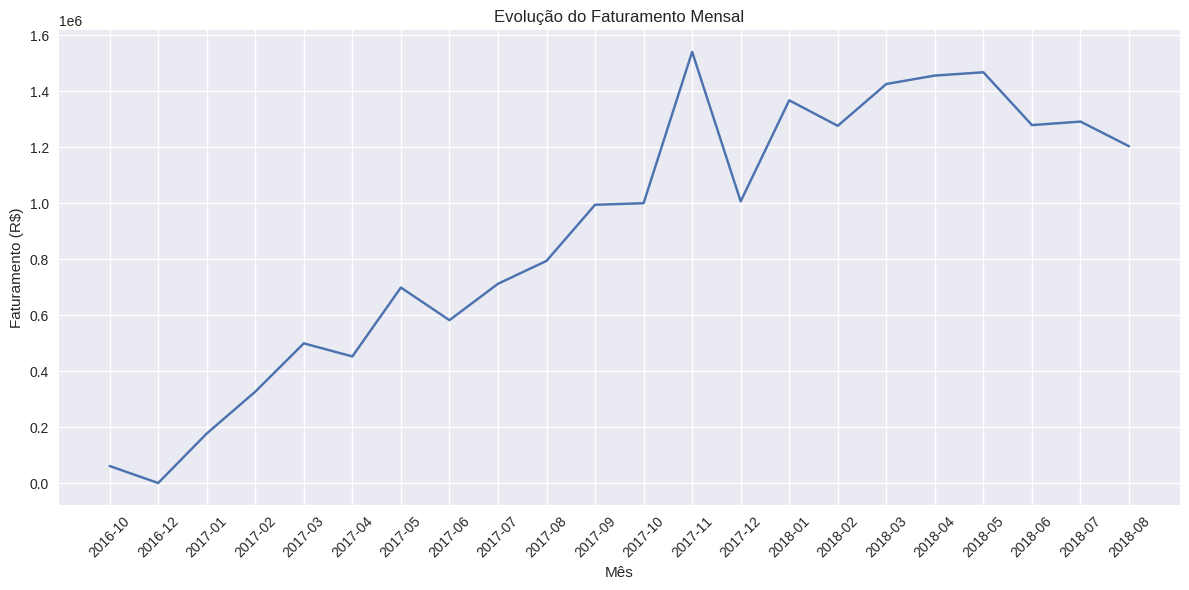

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(
    faturamento_mensal['order_month'],
    faturamento_mensal['payment_value']
)
plt.title('Evolução do Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Faturamento

O faturamento total foi calculado considerando apenas pedidos com status "delivered", garantindo que apenas transações concluídas fossem analisadas.

A análise mensal revela a evolução do faturamento ao longo do tempo, permitindo identificar períodos de crescimento e possíveis sazonalidades nas vendas.

#### O e-commerce gerou um faturamento total R$ 19,618,578.64 no período analisado, indicando uma operação de grande porte.

# Análise 2 — Ticket Médio

Objetivo da análise

Responder à pergunta:

- Em média, quanto cada pedido gera de faturamento para o e-commerce?

Isso ajuda a entender:

- Poder de compra do cliente

- Estratégia de preço

- Impacto de promoções e parcelamentos

Definição de ticket médio (regra de negócio)

Para este projeto, vamos definir:

Ticket médio = faturamento total ÷ número de pedidos

***Importante:
O dataset pode ter mais de uma linha por pedido (ex: múltiplos itens ou pagamentos).

Portanto, vamos calcular o valor total por pedido primeiro.

In [35]:
valor_por_pedido = (
    df_entregues
    .groupby('order_id')['payment_value']
    .sum()
    .reset_index()
)
ticket_medio = valor_por_pedido['payment_value'].mean()
print(f"Ticket médio: R$ {ticket_medio:,.2f}")

Ticket médio: R$ 205.28


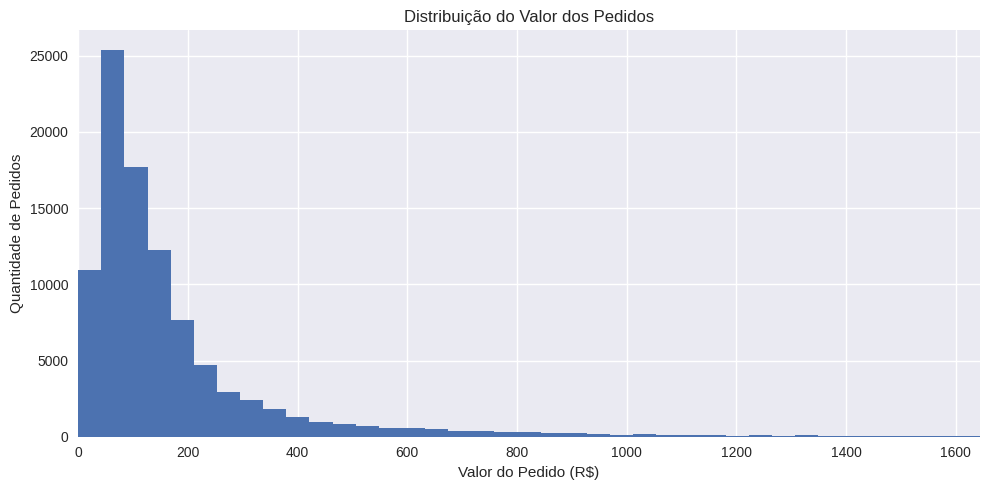

In [45]:
limite_p99 = valor_por_pedido['payment_value'].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    valor_por_pedido['payment_value'],
    bins=np.linspace(0, limite_p99, 40)
)

plt.xlim(0, limite_p99)

plt.title('Distribuição do Valor dos Pedidos')
plt.xlabel('Valor do Pedido (R$)')
plt.ylabel('Quantidade de Pedidos')

plt.tight_layout()
plt.show()

#### Visualização da distribuição do valor dos pedidos

Objetivo do gráfico

- Mostrar como os valores dos pedidos se distribuem, comunicando o comportamento típico dos clientes, sem que valores extremamente raros prejudiquem a leitura.

📌 Decisão analítica (explícita)

- Os valores extremamente altos existem, mas são raríssimos

- Para fins de comunicação visual, o gráfico foca onde está a massa dos dados

Nenhum dado é alterado ou excluído do cálculo do ticket médio
#### A distribuição do valor dos pedidos apresenta forte assimetria à direita, com poucos pedidos de valor extremamente elevado. Para melhor comunicação visual, o gráfico foi limitado ao percentil 99, destacando o comportamento predominante dos clientes.

# Análise 3 — Categorias de Produtos
Volume de vendas × Faturamento

Objetivo da análise

Identificar:

- Quais categorias mais vendem em quantidade

- Quais categorias mais geram faturamento

- Diferenças entre popularidade e valor financeiro

 Preparação dos dados

Partimos do dataframe já consolidado (df), usando:

- product_category_name

- order_id

- price

#### Volume de vendas por categoria
- Mostra categorias mais populares

- Normalmente aparecem categorias de baixo ticket, mas alta recorrência

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


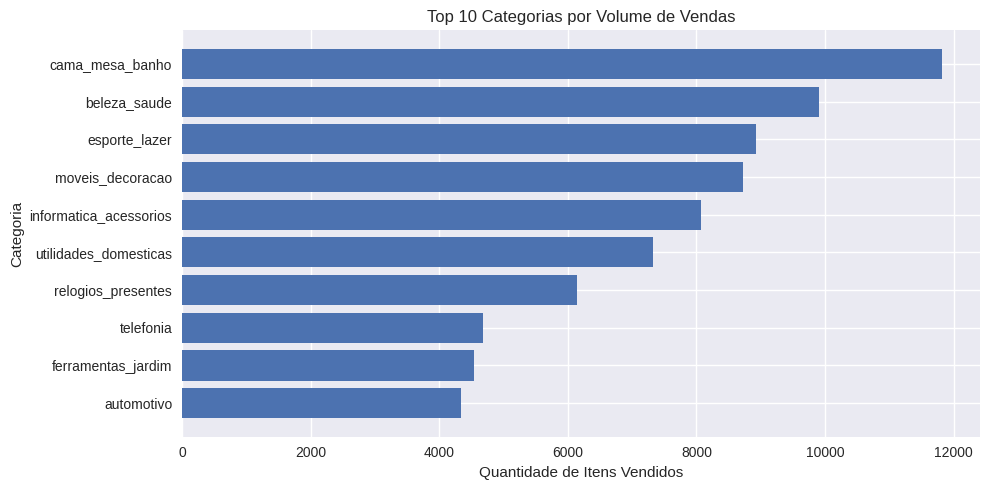

In [46]:
vendas_por_categoria = (
    df.groupby('product_category_name')['order_id']
      .count()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(vendas_por_categoria.index, vendas_por_categoria.values)
plt.gca().invert_yaxis()

plt.title('Top 10 Categorias por Volume de Vendas')
plt.xlabel('Quantidade de Itens Vendidos')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

#### Faturamento por categoria
- Evidencia categorias menos frequentes, porém mais lucrativas

- Pode divergir bastante do ranking por volume

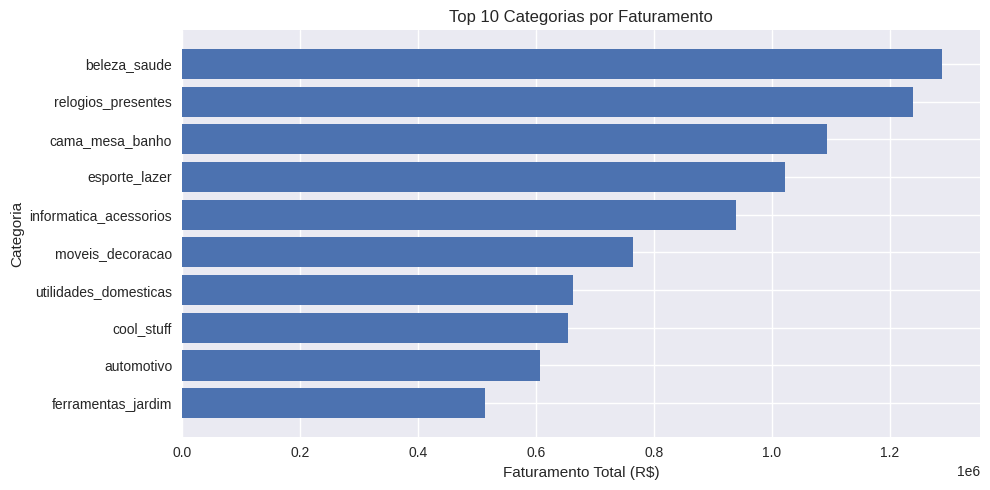

In [47]:
faturamento_por_categoria = (
    df.groupby('product_category_name')['price']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(faturamento_por_categoria.index, faturamento_por_categoria.values)
plt.gca().invert_yaxis()

plt.title('Top 10 Categorias por Faturamento')
plt.xlabel('Faturamento Total (R$)')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

#### Categorias com maior volume de vendas nem sempre são as que mais geram faturamento, indicando diferenças significativas no ticket médio entre categorias.


# Análise 4 — Comportamento Temporal dos Pedidos
Evolução ao longo do tempo

Objetivo da análise:

Entender como o volume de pedidos evolui no tempo, respondendo perguntas como:

- O e-commerce cresceu ao longo dos meses?

- Existem períodos de pico ou queda?

- Há indícios de sazonalidade?


Preparação dos dados

Usaremos:

- order_purchase_timestamp

- order_id

Trabalhando no nível de pedido, não de item.

In [48]:
df['order_month'] = (
    df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)
pedidos_mensais = (
    df.groupby('order_month')['order_id']
      .nunique()
      .reset_index()
)
#usamos nunique para garantir 1 pedido = 1 contagem, mesmo com múltiplos itens.

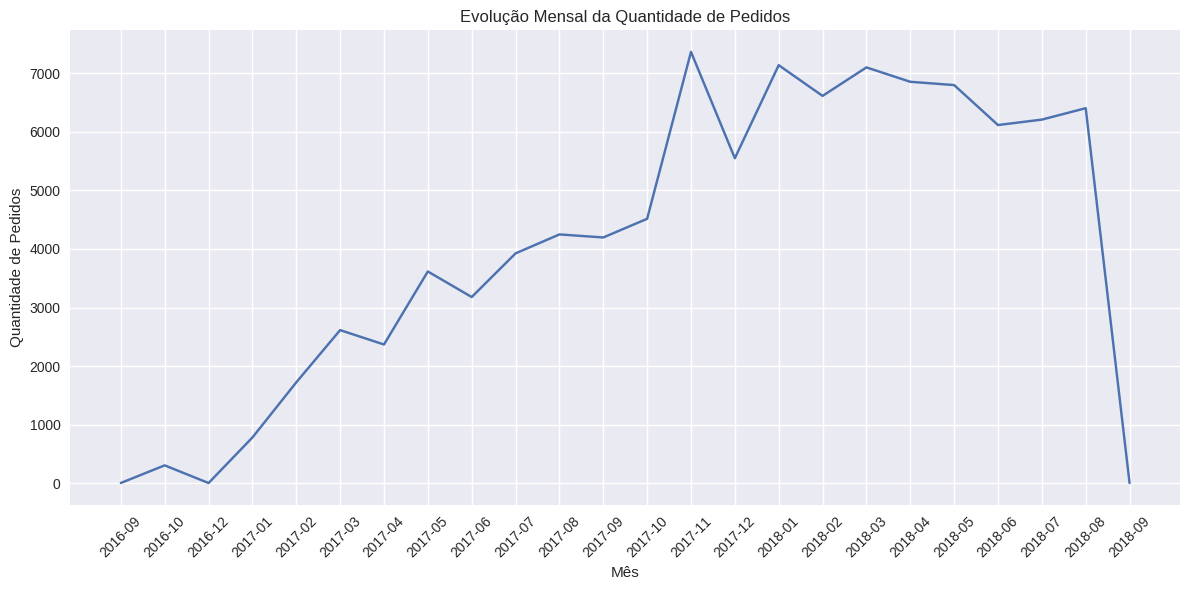

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    pedidos_mensais['order_month'],
    pedidos_mensais['order_id']
)

plt.title('Evolução Mensal da Quantidade de Pedidos')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Pedidos')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### A análise temporal evidencia um crescimento consistente do volume de pedidos ao longo dos anos. No entanto, comparações diretas entre meses de anos diferentes devem ser interpretadas com cautela, pois o crescimento estrutural do negócio influencia fortemente o volume absoluto de pedidos.

# Análise 5 — Prazo de Entrega × Avaliação do Cliente

Objetivo da análise

Responder:

- Atrasos na entrega impactam a nota dada pelo cliente?

Essa é uma pergunta 100% de negócio.

 Preparação dos dados

Vamos trabalhar no nível do pedido, usando:

- order_purchase_timestamp

- order_delivered_customer_date

- order_estimated_delivery_date

- review_score

In [50]:
#LOGICA DA METRICA DE ATRASO: se entrega depois da data estimada → atraso (positivo)--- se entrega antes ou no prazo → zero ou negativo

df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days


df['delivery_status'] = df['delivery_delay_days'].apply(
    lambda x: 'Atrasado' if x > 0 else 'No prazo'
)


avaliacao_por_entrega = (
    df.groupby('delivery_status')['review_score']
      .mean()
      .reset_index()
)

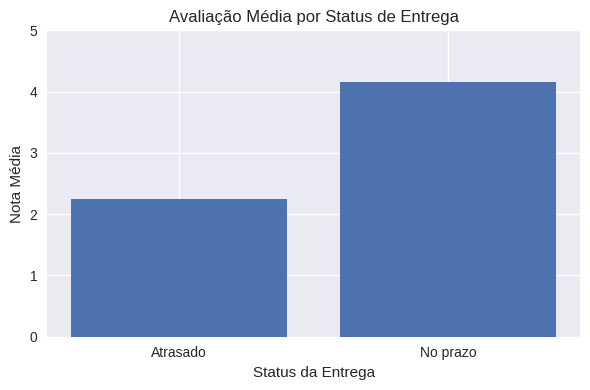

In [51]:
plt.figure(figsize=(6, 4))
plt.bar(
    avaliacao_por_entrega['delivery_status'],
    avaliacao_por_entrega['review_score']
)

plt.title('Avaliação Média por Status de Entrega')
plt.xlabel('Status da Entrega')
plt.ylabel('Nota Média')

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

#### A análise evidencia um impacto significativo do prazo de entrega na avaliação dos clientes. Pedidos entregues fora do prazo apresentam nota média de aproximadamente 2.2, enquanto pedidos entregues no prazo atingem média de 4.1, indicando que atrasos afetam diretamente a percepção da experiência de compra.


## Resumo Executivo
Este projeto analisou dados do e-commerce Olist com o objetivo de compreender padrões de vendas, comportamento de preços, evolução temporal dos pedidos e o impacto da logística na experiência do cliente. Ao longo das análises, foi identificado crescimento consistente no volume de pedidos, diferenças relevantes entre categorias em volume e faturamento, além de um forte impacto negativo de atrasos na entrega sobre as avaliações dos clientes.


## Principais Insights
- O volume de pedidos apresentou crescimento ao longo do período analisado, indicando expansão do e-commerce.
- Categorias mais vendidas em quantidade não são necessariamente as que mais geram faturamento, evidenciando diferenças de ticket médio.
- A distribuição dos valores dos pedidos é concentrada em faixas de preço mais baixas, com poucos pedidos de alto valor.
- O prazo de entrega mostrou impacto direto na satisfação do cliente: pedidos atrasados receberam nota média significativamente menor do que pedidos entregues no prazo.

## Possíveis Próximos Passos
- Realizar uma análise sazonal separando crescimento estrutural de efeitos mensais.
- Investigar causas operacionais dos atrasos na entrega (região, vendedor, transportadora).
- Avaliar a relação entre categoria do produto e probabilidade de atraso.
- Criar dashboards interativos para acompanhamento dos indicadores identificados.